In [2]:
import os
import sys

# Get the absolute path of the directory containing the notebook (notebooks/)
current_dir = os.path.abspath('')

# Add the parent directory (SingleWordProductionDutch/) to the system path
# This allows Python to find 'src'
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)


%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.signal
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from scipy.signal import welch

import pandas as pd
import numpy.matlib as matlib
import scipy
import scipy.stats
import scipy.io.wavfile
import scipy.fftpack
from scipy.stats import pearsonr
from pynwb import NWBHDF5IO



from reconstruction_minimal import reconstruct
from notebookfunctions import *

import gc

feat_path = r'./features'
result_path = r'./results'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:



winL = 0.05
frameshift = 0.01
modelOrder = 4
stepSize = 5
path_bids = '/Users/lisa/Documents/DSAI_year2/Marble/SingleWordProductionDutch/SingleWordProductionDutch-iBIDS'
path_output = r'./features'
pts = ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05','sub-06','sub-07', 'sub-08', 'sub-09', 'sub-10']




for pt in pts: 
    io = NWBHDF5IO(os.path.join(path_bids,pt,'ieeg',f'{pt}_task-wordProduction_ieeg.nwb'), 'r')
    nwbfile = io.read()
    data = nwbfile.acquisition['iEEG'].data
    #io.close()
    
    initParams_list = get_initParams(pt)
    feat = extractSSPE(data, initParams_list, include_phase = False, include_pac = False)
    np.save(os.path.join(path_output,f'{pt}_onlyAMP_SSPEfeat.npy'), feat)
    io.close()
    del data
    del feat
    gc.collect()



reconstruct(pts=pts, feat_suffix='_onlyAMP_SSPEfeat.npy', unstacked =True, saveAs='only_AMP_sppe')








(10, 10, 23)
(10, 10, 23)


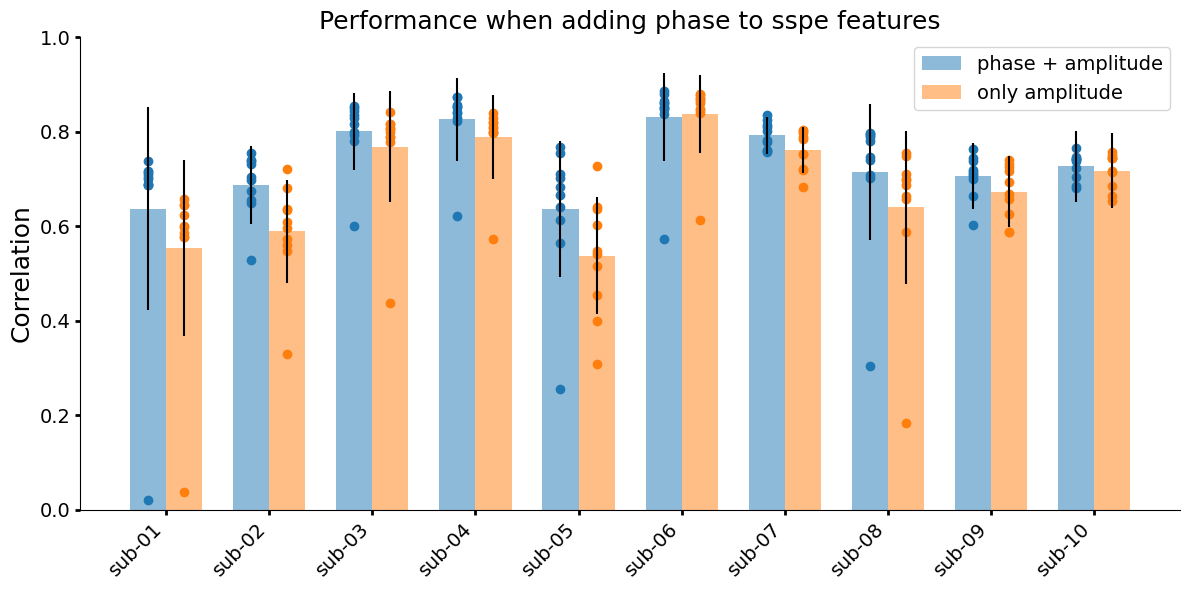

In [4]:
viz_compare_results('PHASE_sppe', 'only_AMP_sppe', name_a = 'phase + amplitude', name_b = 'only amplitude', title = 'Performance when adding phase to sspe features')

#Documents/DSAI_year2/SingleWordProductionDutch-1/results/phase_sppelinearResults.npy

(10, 10, 23)
(10, 10, 23)


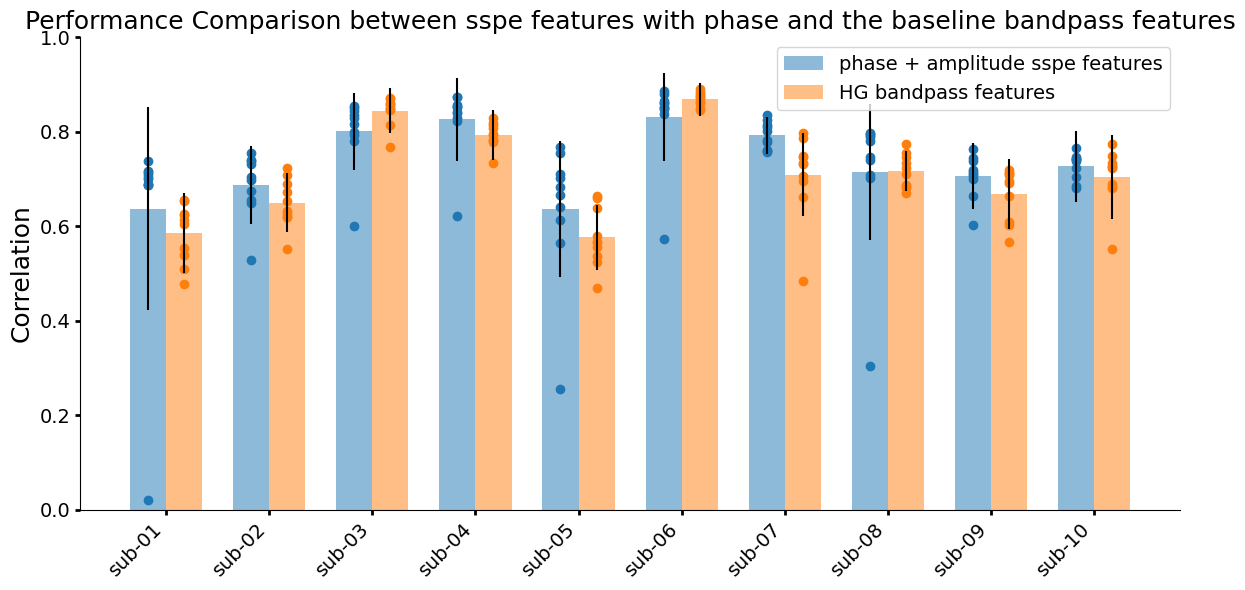

In [5]:
viz_compare_results('phase_sppe', 'Bandpass_PLS',name_a = 'phase + amplitude sspe features', name_b = 'HG bandpass features', title = 'Performance Comparison between sspe features with phase and the baseline bandpass features')


In [ ]:

path_output = r'./features'
pts = ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05','sub-06','sub-07', 'sub-08', 'sub-09', 'sub-10']




reconstruct(pts=['sub-01'], n_comp =5, feat_suffix='_PCA_SSPEfeat.npy', unstacked =True, saveAs='dont')


(10, 10, 23)
(10, 10, 23)


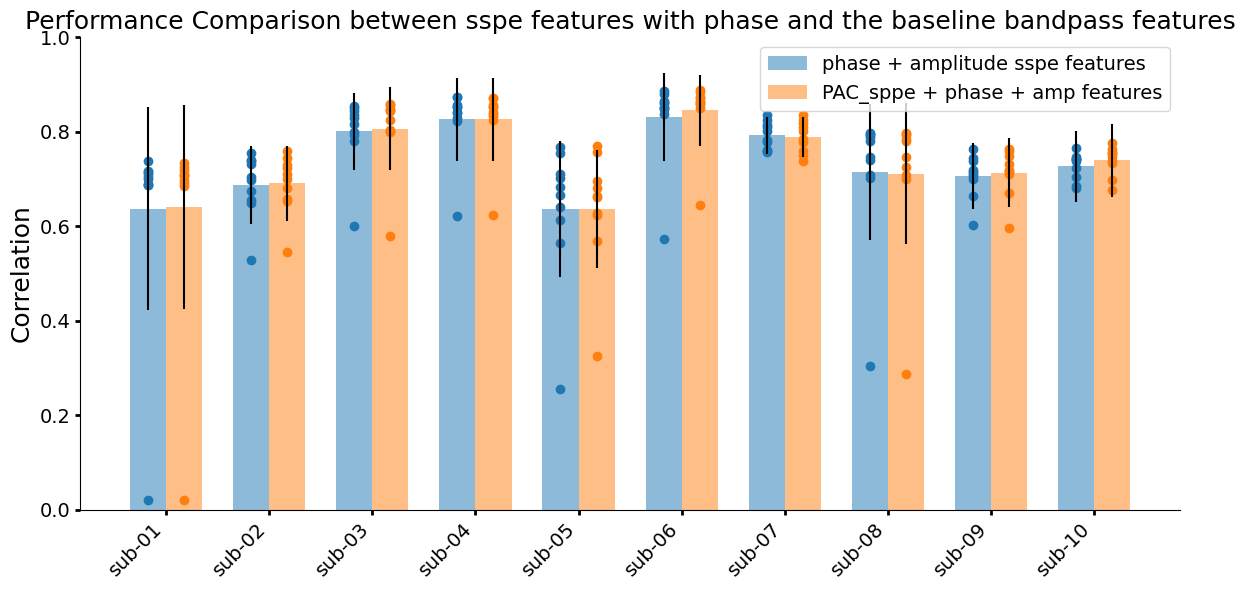

In [7]:
viz_compare_results('phase_sppe', 'PAC_sppe',name_a = 'phase + amplitude sspe features', name_b = 'PAC_sppe + phase + amp features', title = 'Performance Comparison between sspe features with phase and the baseline bandpass features')


(10, 10, 23)
(10, 10, 23)


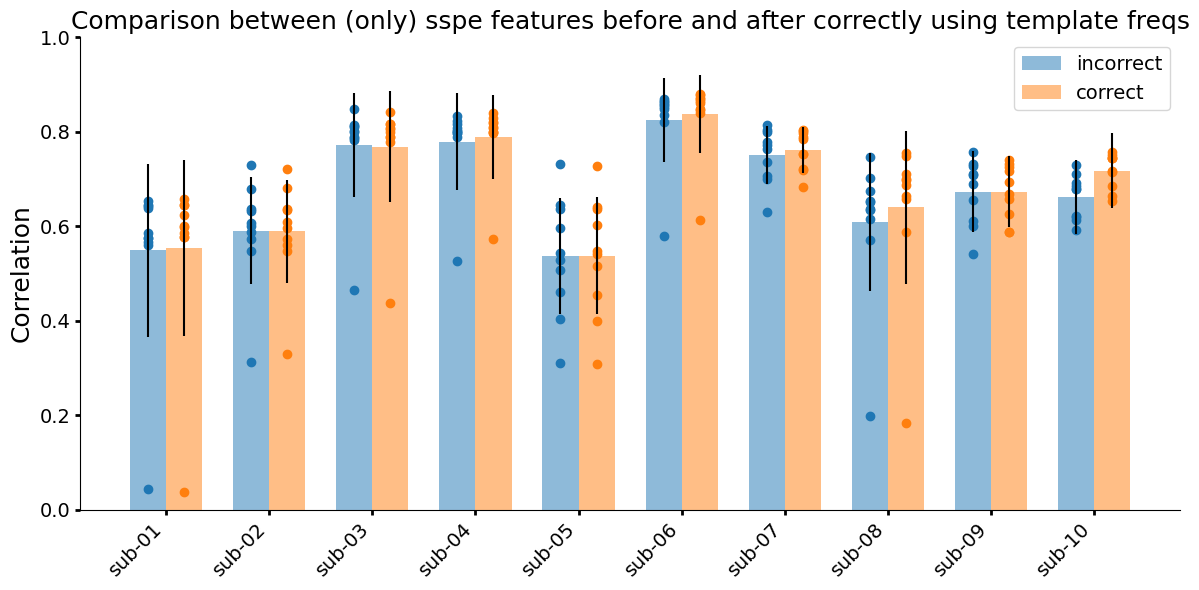

In [8]:
viz_compare_results('SSPE_PLS', 'only_AMP_sppe',name_a = 'incorrect', name_b = 'correct', title = 'Comparison between (only) sspe features before and after correctly using template freqs')



(10, 10, 23)
(10, 10, 23)


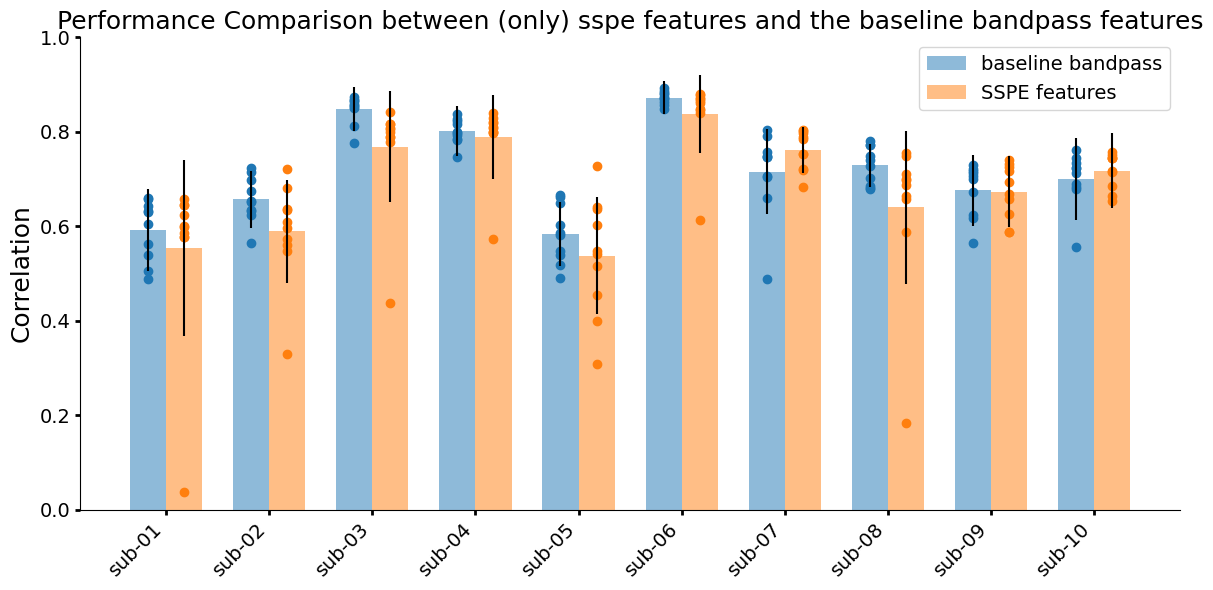

In [9]:
viz_compare_results('CausalHG', 'only_AMP_sppe',name_a = 'baseline bandpass', name_b = 'SSPE features', title = 'Performance Comparison between (only) sspe features and the baseline bandpass features')






model: HG bandpass baseline, overall mean r: 0.7099
model: Amplitude SSR features, overall mean r: 0.7183
model: Amplitude and phase SSR features, overall mean r: 0.7621
model: Amplitude, phase and PAC SSR features, overall mean r: 0.765


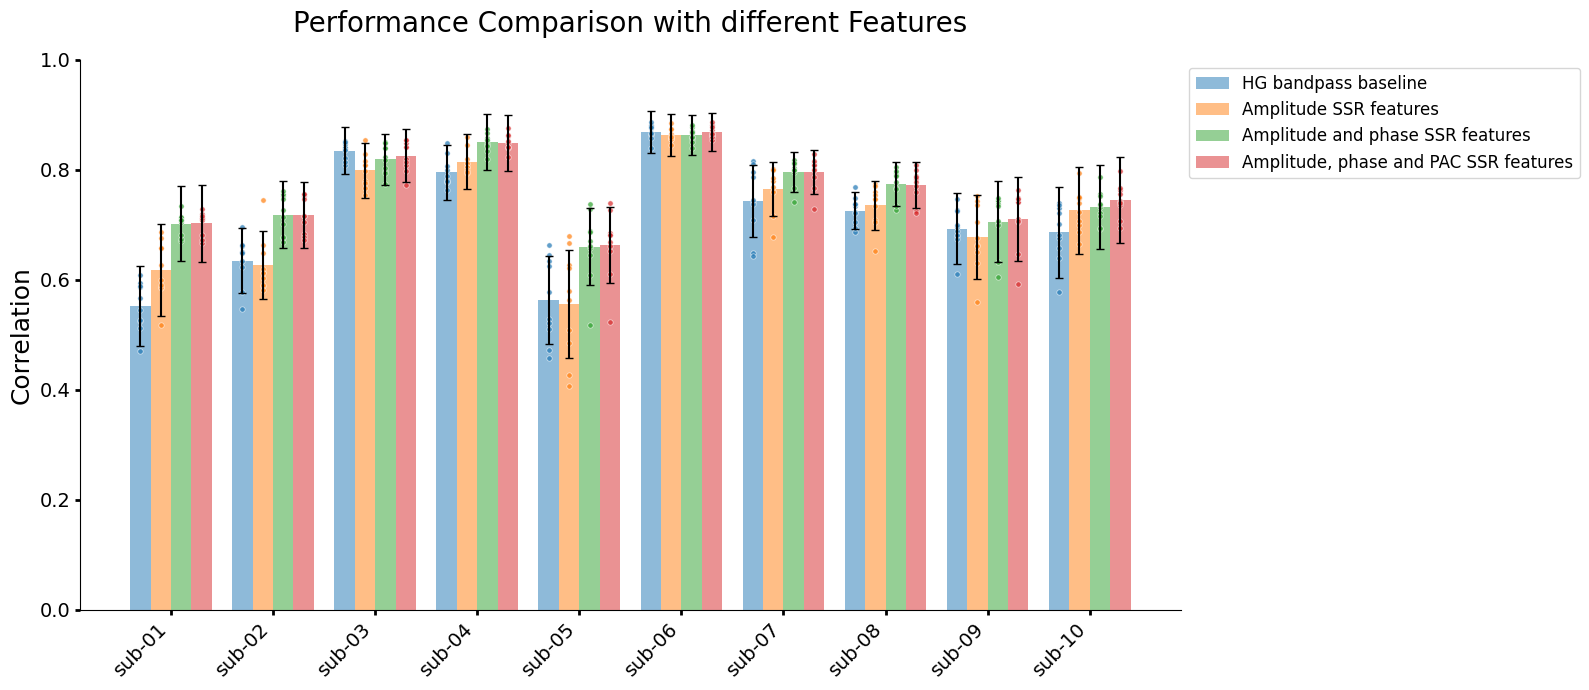

In [10]:


prefixes = ['CausalHG_cropped', 'only_AMP_sppe_cropped', 'phase_sppe_cropped', 'PAC_sspe_cropped']
names = [
    'HG bandpass baseline', 
    'Amplitude SSR features', 
    'Amplitude and phase SSR features', 
    'Amplitude, phase and PAC SSR features'
]
title = "Performance Comparison with different Features"


# load and process data
results = []
for i, pre in enumerate(prefixes):
    res = np.load(os.path.join(path_result, f'{pre}linearResults.npy'))
    results.append(res)
    print(f'model: {names[i]}, overall mean r: {round(np.mean(res),4)}')

# Calculate means and stds for each model
means = [np.mean(res, axis=(1, 2)) for res in results]
stds = [np.std(res, axis=(1, 2)) for res in results]


# Plotting 
n_models = len(prefixes)
n_subs = len(means[0])
x = np.arange(n_subs)

# Adjust width and offsets based on number of models
width = 0.2  
offsets = np.linspace(-(width * (n_models - 1) / 2), (width * (n_models - 1) / 2), n_models)

fig, ax = plt.subplots(figsize=(16, 7))

for i in range(n_models):
    # Plot Bars
    ax.bar(x + offsets[i], means[i], width, yerr=stds[i], 
           label=names[i], alpha=0.5, color=f'C{i}', capsize=3)
    
    # Add scatter points for individual observations
    for p in range(n_subs):
        vals = np.mean(results[i][p], axis=1)
        ax.scatter(np.repeat(p + offsets[i], len(vals)), vals, 
                   color=f'C{i}', s=15, alpha=0.7, edgecolors='white', linewidth=0.5)

# Styling
ax.set_ylabel('Correlation', fontsize=18)
ax.set_title(title, fontsize=20, pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'sub-{i+1:02d}' for i in x], rotation=45, ha='right', fontsize=14)
ax.set_ylim(0, 1)

# Clean up spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14, width=2)

# Legend and Layout
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Save and Show
plt.savefig(os.path.join(result_path, 'comparison_results_ABCD.png'), dpi=600, bbox_inches='tight')
plt.show()

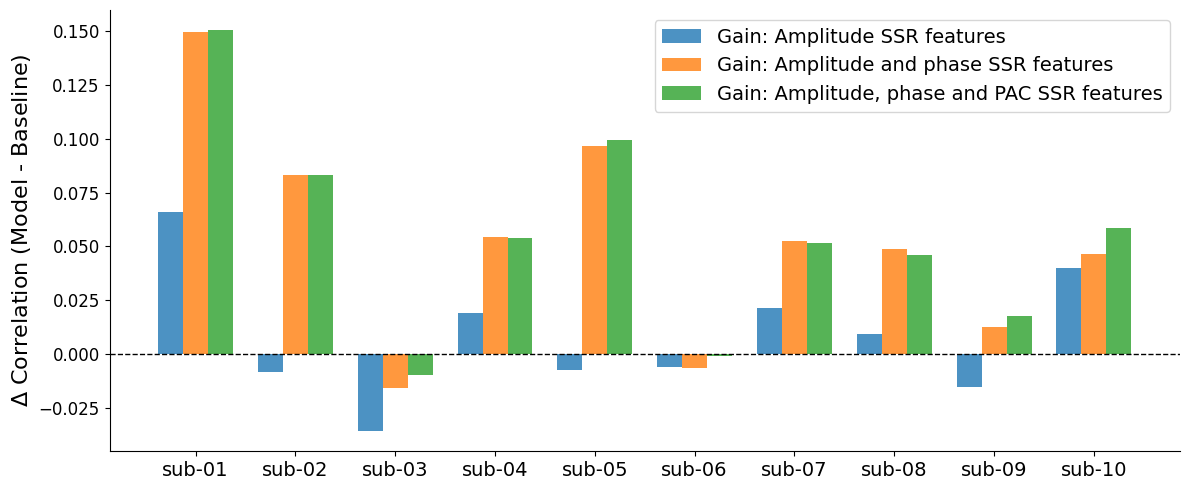

In [11]:

# calculate mean for each model
subj_means = [np.mean(res, axis=(1, 2)) for res in results]

# calculate delta
delta_b = subj_means[1] - subj_means[0]
delta_c = subj_means[2] - subj_means[0]
delta_d = subj_means[3] - subj_means[0]

deltas = [delta_b, delta_c, delta_d]
delta_names = names[1:] # skip the baseline name

x = np.arange(len(subj_means[0]))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

for i, delta in enumerate(deltas):
    ax.bar(x + (i-1)*width, delta, width, label=f'Gain: {delta_names[i]}', alpha=0.8)

ax.axhline(0, color='black', lw=1, ls='--') # Baseline indicator
ax.set_ylabel('$\Delta$ Correlation (Model - Baseline)', fontsize=16)
#ax.set_title('Performance Improvement Relative to HG Bandpass Baseline', fontsize=16)
ax.set_xticks(x)
ax.tick_params(axis='both', labelsize=12)
ax.set_xticklabels([f'sub-{i+1:02d}' for i in x],fontsize=14)


# Place the legend inside the chart area
ax.legend(loc='best', frameon=True, fontsize=14)


ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(result_path, 'comparison_phase_PAC_amp.png'), dpi=600, bbox_inches='tight')

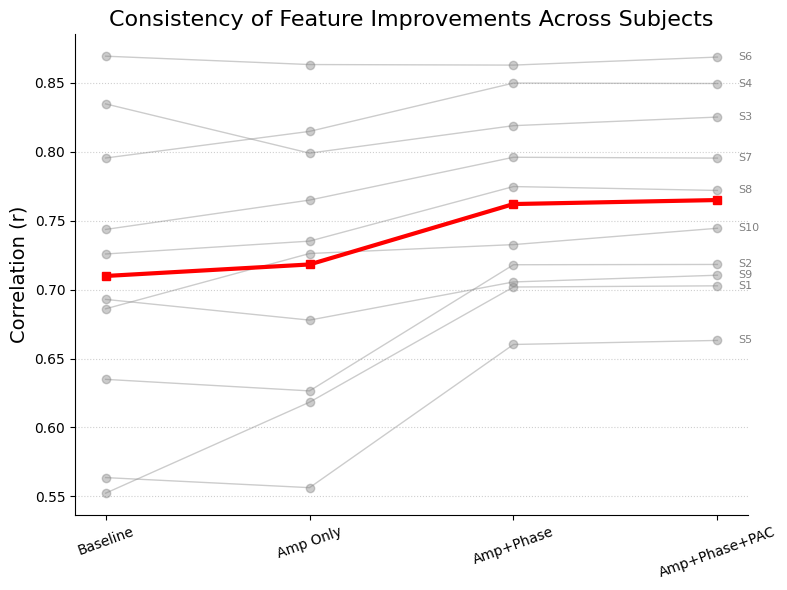

In [12]:

plot_data = np.array(subj_means).T 

fig, ax = plt.subplots(figsize=(8, 6))

# plot individual subject lines
for i in range(plot_data.shape[0]):
    ax.plot(range(4), plot_data[i, :], marker='o', color='gray', alpha=0.4, lw=1)
    ax.text(3.1, plot_data[i, 3], f'S{i+1}', verticalalignment='center', fontsize=8, color='gray')

# plot the mean red
grand_mean = np.mean(plot_data, axis=0)
ax.plot(range(4), grand_mean, marker='s', color='red', lw=3, label='Mean', zorder=10)

# Styling
ax.set_xticks(range(4))
ax.set_xticklabels(['Baseline', 'Amp Only', 'Amp+Phase', 'Amp+Phase+PAC'], rotation=20)
ax.set_ylabel('Correlation (r)', fontsize=14)
ax.set_title('Consistency of Feature Improvements Across Subjects', fontsize=16)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:

from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests


# 1: Is Full SSPE better than the Baseline?
t_framework, p_framework = ttest_rel(subj_means[3], subj_means[0])


# 2: Do Phase and PAC add incremental value to SSPE?
# We do 2 specific tests here, so we will correct for 2 comparisons.
t_phase, p_phase = ttest_rel(subj_means[2], subj_means[1]) # Amp+Phase vs Amp Only
t_pac, p_pac = ttest_rel(subj_means[3], subj_means[2])     # Amp+Phase+PAC vs Amp+Phase

# Correcting just these two incremental step tests using Holm-Bonferroni
reject_steps, p_corrected_steps, _, _ = multipletests([p_phase, p_pac], alpha=0.05, method='holm')


# Print the results
print("=====================================================================")
print("QUESTION 1: SSPE Framework vs. Traditional Bandpass Baseline")
print("=====================================================================")
print(f"Model 3 (Full SSPE: 0.7401) vs. Model 0 (HG Bandpass: 0.7177)")
print(f"  t-statistic : {t_framework:+.4f}")
print(f"  p-value     : {p_framework:.5f} " + ("(SIGNIFICANT)" if p_framework < 0.05 else "(NOT SIGNIFICANT)"))

print("\n=====================================================================")
print("QUESTION 2: Incremental Value of Phase & PAC inside SSPE")
print("=====================================================================")

print(f"Step 1: Does adding Phase help? (Model 2 vs. Model 1)")
print(f"  t-statistic : {t_phase:+.4f}")
print(f"  Raw p-value : {p_phase:.5f}")
print(f"  Corrected p : {p_corrected_steps[0]:.4f} " + ("(SIGNIFICANT)" if reject_steps[0] else "(NOT SIGNIFICANT)"))
print("-" * 60)

print(f"Step 2: Does adding PAC help? (Model 3 vs. Model 2)")
print(f"  t-statistic : {t_pac:+.4f}")
print(f"  Raw p-value : {p_pac:.5f}")
print(f"  Corrected p : {p_corrected_steps[1]:.4f} " + ("(SIGNIFICANT)" if reject_steps[1] else "(NOT SIGNIFICANT)"))
print("=====================================================================")

QUESTION 1: SSPE Framework vs. Traditional Bandpass Baseline
Model 3 (Full SSPE: 0.7401) vs. Model 0 (HG Bandpass: 0.7177)
  t-statistic : +3.6361
  p-value     : 0.00543 (SIGNIFICANT)

QUESTION 2: Incremental Value of Phase & PAC inside SSPE
Step 1: Does adding Phase help? (Model 2 vs. Model 1)
  t-statistic : +3.8122
  Raw p-value : 0.00414
  Corrected p : 0.0083 (SIGNIFICANT)
------------------------------------------------------------
Step 2: Does adding PAC help? (Model 3 vs. Model 2)
  t-statistic : +2.1107
  Raw p-value : 0.06400
  Corrected p : 0.0640 (NOT SIGNIFICANT)


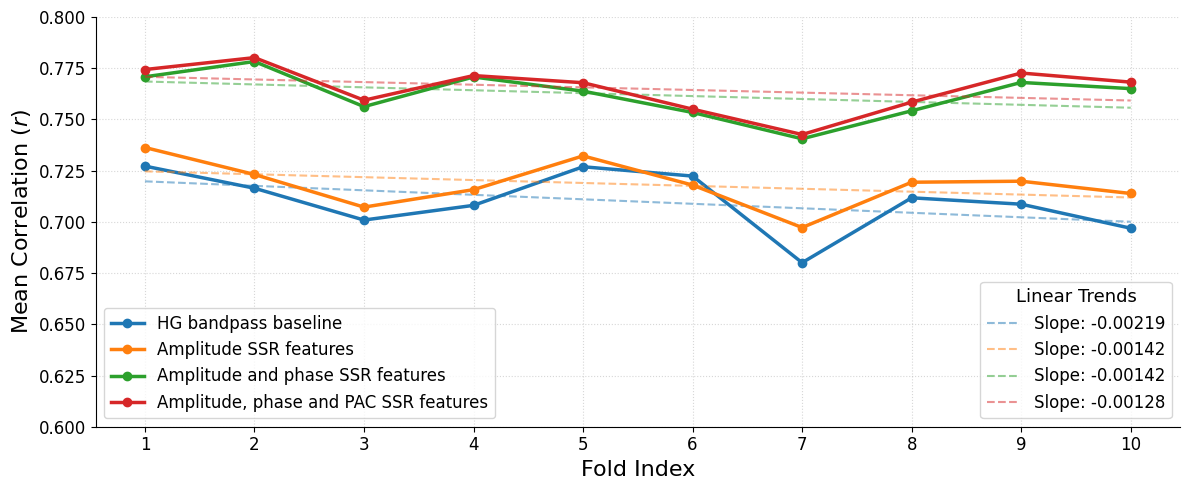

--- Stability Metrics ---
Gains over baseline across all 10 folds: [0.0471 0.0638 0.0585 0.0633 0.041  0.0327 0.0626 0.0467 0.064  0.0713]
Min gain: 0.0327 (Fold 6)
Max gain: 0.0713 (Fold 10)
Mean gain across folds: 0.0551 ± 0.0118
Full model trajectory slope per fold:
pac: -0.00128
phase: -0.00142
amp: -0.00142
baseline: -0.00219


In [14]:

n_folds = results[0].shape[1]
folds = np.arange(1, n_folds + 1)

fig, ax = plt.subplots(figsize=(12, 5))

trend_handles = []
trend_labels = []

for i, res in enumerate(results):
    # Average over observations (axis 2) -> shape: (n_subjects, n_folds)
    sub_fold_matrix = np.mean(res, axis=2)
    
    
    # Calculate grand mean and SEM across subjects for each fold
    grand_mean_per_fold = np.mean(sub_fold_matrix, axis=0)
    sem_per_fold = np.std(sub_fold_matrix, axis=0) / np.sqrt(sub_fold_matrix.shape[0])
    
    # Plot the group-level trajectory
    ax.plot(folds, grand_mean_per_fold, marker='o', linewidth=2.5, 
            label=names[i], color=f'C{i}')
    #ax.fill_between(folds, grand_mean_per_fold - sem_per_fold, grand_mean_per_fold + sem_per_fold, color=f'C{i}', alpha=0.15)
    # Step 4: Fit and plot the linear trendline (Dotted Line)
    slope, intercept = np.polyfit(folds, grand_mean_per_fold, 1)
    trend, = ax.plot(folds, slope * folds + intercept, linestyle='--', 
                     color=f'C{i}', alpha=0.5, linewidth=1.5)
    
    # Keep track of trendline data for the second legend
    trend_handles.append(trend)
    trend_labels.append(f'Slope: {slope:.5f}')

# Styling
ax.set_xlabel('Fold Index', fontsize=16)
ax.set_ylabel('Mean Correlation ($r$)', fontsize=16)
#ax.set_title('Model Performance Stability Across Folds', fontsize=16, pad=15)
ax.set_xticks(folds)
ax.set_ylim(0.6, 0.80) 
ax.grid(axis='both', linestyle=':', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)


#ax.legend(fontsize=11, loc='lower left')
# Legend 1: Main models (Bottom Left)
leg1 = ax.legend(fontsize=12, loc='lower left')

# Legend 2: Trendlines & Slopes (Bottom Right)
# We must manually add the first legend back as an artist, otherwise it gets overwritten
ax.add_artist(leg1)
ax.legend(trend_handles, trend_labels, fontsize=12, loc='lower right', 
          title="Linear Trends", title_fontsize=13)

ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig(os.path.join(result_path, 'fold_stability_trends.png'), dpi=600)
plt.show()


# Compute the subject-fold matrices for each model (shape: n_subjects, n_folds)
baseline_sf = np.mean(results[0], axis=2)
amp_sf = np.mean(results[1], axis=2)
phase_sf = np.mean(results[2], axis=2)
pac_sf = np.mean(results[3], axis=2)

# Get group means per fold
mean_baseline = np.mean(baseline_sf, axis=0)
mean_pac = np.mean(pac_sf, axis=0)
mean_phase = np.mean(phase_sf, axis=0)
mean_amp = np.mean(amp_sf, axis=0)

# 1. Calculate the improvement (gain) over baseline for every single fold
gains_per_fold = mean_pac - mean_baseline

print("--- Stability Metrics ---")
print(f"Gains over baseline across all 10 folds: {np.round(gains_per_fold, 4)}")
print(f"Min gain: {round(np.min(gains_per_fold), 4)} (Fold {np.argmin(gains_per_fold)+1})")
print(f"Max gain: {round(np.max(gains_per_fold), 4)} (Fold {np.argmax(gains_per_fold)+1})")
print(f"Mean gain across folds: {round(np.mean(gains_per_fold), 4)} ± {round(np.std(gains_per_fold), 4)}")

# 2. Check for a downward trend in the full model using a simple linear fit slope
slopepac, _ = np.polyfit(folds, mean_pac, 1)
slopephase, _ = np.polyfit(folds, mean_phase, 1)
slopeamp, _ = np.polyfit(folds, mean_amp, 1)
slopebase, _ = np.polyfit(folds, mean_baseline, 1)

print("Full model trajectory slope per fold:")
print(f"pac: {round(slopepac, 5)}")
print(f"phase: {round(slopephase, 5)}")
print(f"amp: {round(slopeamp, 5)}")
print(f"baseline: {round(slopebase, 5)}")



In [ ]:

reconstruct(pts=None, feat_suffix='_PHASE_SSPEfeat.npy', unstacked =True, saveAs='phase_sppe_cropped')

reconstruct(pts=None, feat_suffix='_onlyAMP_SSPEfeat.npy', unstacked =True, saveAs='only_AMP_sppe_cropped')

reconstruct(pts=None, feat_suffix='_PCA_SSPEfeat.npy', unstacked =True, saveAs='PAC_sspe_cropped')

reconstruct(pts=None, feat_suffix='_causalfeat.npy', unstacked =True, saveAs='CausalHG_cropped')

In [15]:

# Define prefixes and paths
prefixes = ["CausalHG_cropped", "only_AMP_sppe_cropped", "phase_sppe_cropped", "PAC_sspe_cropped"]
# Mapping prefixes to meaningful names for your report
model_names = {
    "CausalHG_cropped": "HG Bandpass (Baseline)",
    "only_AMP_sppe_cropped": "Amplitude Only SSPE",
    "phase_sppe_cropped": "Amp + Phase SSPE",
    "PAC_sspe_cropped": "Amp + Phase + PAC SSPE"
}

result_path = '/Users/lisa/Documents/DSAI_year2/SingleWordProductionDutch-1/results'

print(f"{'Model Framework':<35} | {'Mean r':<8} | {'Random Control (mean ± sd)':<28} | {'Group Z-score':<12}")
print("-" * 93)

# Loop through each model type
for prefix in prefixes:
    # Load the specific results for this framework
    allRes = np.load(os.path.join(result_path, f'{prefix}linearResults.npy'))
    randomControl = np.load(os.path.join(result_path, f'{prefix}randomResults.npy'))
    
    # Track metrics across all 10 participants
    sub_model_means = []
    sub_rand_means = []
    sub_rand_stds = []
    
    for p in range(10):
        # Calculate participant-specific means
        sub_model_means.append(allRes[p].mean())
        sub_rand_means.append(randomControl[p].mean())
        sub_rand_stds.append(randomControl[p].std())
        
    # Calculate Group-Level Grand Means
    group_model_mean = np.mean(sub_model_means)
    group_rand_mean = np.mean(sub_rand_means)
    group_rand_std = np.mean(sub_rand_stds) # Average standard deviation of the chance distribution
    
    # Group Z-score: how many standard deviations the group mean is from the group chance mean
    group_z = (group_model_mean - group_rand_mean) / group_rand_std
    
    # Print formatted row
    name = model_names.get(prefix, prefix)
    rand_str = f"{group_rand_mean:.4f} ± {group_rand_std:.4f}"
    print(f"{name:<35} | {group_model_mean:.4f}  | {rand_str:<28} | {group_z:.2f}")

Model Framework                     | Mean r   | Random Control (mean ± sd)   | Group Z-score
---------------------------------------------------------------------------------------------
HG Bandpass (Baseline)              | 0.7099  | -0.0016 ± 0.1595             | 4.46
Amplitude Only SSPE                 | 0.7183  | 0.0009 ± 0.1605              | 4.47
Amp + Phase SSPE                    | 0.7621  | -0.0017 ± 0.1588             | 4.81
Amp + Phase + PAC SSPE              | 0.7650  | -0.0001 ± 0.1584             | 4.83


In [ ]:
# Calculate the gain over baseline (Model - Baseline) for each subject
baseline_means = np.mean(results[0], axis=(1, 2)) # Shape: (n_subs,)

# Loop through the three feature models shown in the bar plot
for i in [1, 2, 3]:
    model_means = np.mean(results[i], axis=(1, 2))
    gains = model_means - baseline_means
    
    print(f"\n--- {names[i]} ---")
    print(f"Max improvement: {round(np.max(gains), 4)} (sub-{np.argmax(gains)+1:02d})")
    print(f"Sub-03 gain: {round(gains[2], 4)}")
    print(f"Sub-06 gain: {round(gains[5], 4)}")
    print(f"Mean overall improvement across all subjects: {round(np.mean(gains), 4)}")